# 🧑‍🏫 Algorithmes de Classification

Dans le notebook précédent, on a vu ce qu'est la classification et comment préparer les données. Maintenant, la vraie question est : **quel algorithme utiliser ?**

# **1. Pourquoi plusieurs algorithmes ?**

Avec tout les différents problèmes de classification existant, il serait injuste de dire qu'il existe un algorithme de classification qui soit toujours le meilleur. 

On appelle ce phénomène le *No Free Lunch Theorem* : pour tout algorithme qui performe bien sur un type de problème, il en existe un autre qui performe mieux sur un problème différent.

En pratique, le choix d'un algorithme dépend de plusieurs facteurs :

- La **taille** du jeu de données (petit ou grand nombre d'observations)
- Le **nombre de variables (features)** disponibles
- la complexité des relations entre les données (frontière simple ou très complexe)
- le besoin de comprendre le modèle (interprétabilité)
- Le temps disponible pour l'**entraînement** et la **prédiction**

L'objectif de ce notebook est de comprendre comment trois algorithmes classiques abordent le même problème, et de comparer leurs forces et limites. Les 3 algorithmes sont les suivants:
- le *K-Nearest Neighboors (KNN)*
- le *Support Vector Machine (SVM)*
- le Random Forest

---

## 2. Le problème commun

Afin de comparer les 3 algorithmes de façon équitable, nous allons les entraines et les évaluer sur le même jeu de données. Nous allons donc utiliser un jeu de données synthétique simplea avec 2 features et 2 classes.

### 2.1 Le jeu de données make_moons

Pour ce notebook, nous utilisons un jeu de données synthétique appelé make_moons.

Ce jeu de donnée est souvent utilisé en apprentissage automatique pour illustrer des problèmes de classification non linéaire. Le terme "non-linéaire" signifie simplement que la frontière de décision ne correspond pas à une ligne droite. Cela rend la tâche de classification plus hardue.

Il génère deux classes disposées en forme de demi-lunes. Dans le cadre de cet exercice, les 2 classes seront simplement définies comme **classe 0** et **classe 1**.

En travaillant sur le même problème, nous pourrons visualler comment chaque modèle trace sa frontière de décision différemment.


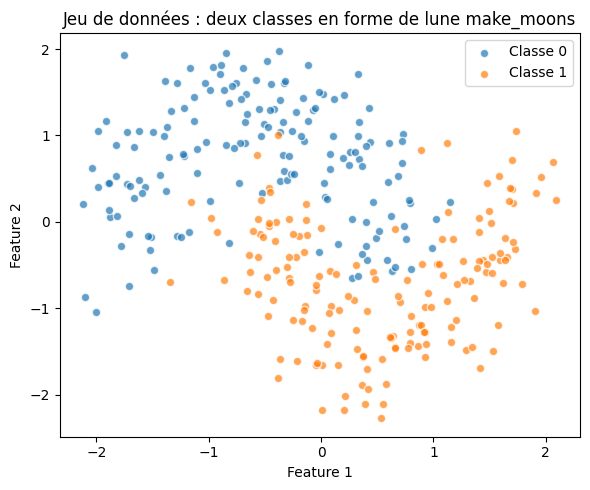

In [1]:
# --- Imports globaux ---
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# --- Générer le dataset ---
# make_moons génère deux classes en forme de croissants de lune
# C'est un problème non-linéaire classique pour tester les classificateurs
X, y = make_moons(n_samples=400, noise=0.25, random_state=42)

# --- Diviser en train/test ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Standardiser ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- Visualiser le dataset ---
plt.figure(figsize=(6, 5))
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], label='Classe 0', alpha=0.7, edgecolors='white')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], label='Classe 1', alpha=0.7, edgecolors='white')
plt.title('Jeu de données : deux classes en forme de lune make_moons')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()

## 3. K-Nearest Neighbors (KNN)

### 3.1 Intuition

Pour comprendre ce type d'algorithme de classification, voici une mise en situation.

Imagine que quelqu'un arrive dans une nouvelle ville et qu'il aimerait savoir si le quartier est plutôt calme ou animé. Une façon simple de le deviner serait de regarder les maisons autour de soi: si la plupart sont calmes, il pourrait supposer que le reste du quartier l'est aussi.

Le modèle KNN fonctionne de cette manière! En fait, pour classer une nouvelle observation, il regarder les $k$ observations les plus proches dans le jeu de données et attribue la classe majoritaire parmi elles.

### 3.2 Comment fonctionne-t-il ?

le KNN est un algorithme qu'on appelle **lazy learner**. C'est à dire qu'il ne construit pas de modèle explicite pendant l’entraînement. Il se contente de mémoriser les données.

Lorsqu'une prédiction est demandée, il compare la nouvelle observation à toutes les données d'entrainement en utilisant une mesure de distance, soit la **distance euclidienne**.

Pour les intéressés, voici sa formule:

$$d(\mathbf{x}, \mathbf{x'}) = \sqrt{\sum_{i=1}^{n} (x_i - x'_i)^2}$$

(généré grâce à l'IA).  
Pour plus d'information sur la distance euclidienne, vous pouvez contacter ce site: XXXXXX

Voici les étapes de prédictions:  
1. Calculer la distance entre le nouveau point et tous les points d’entraînement
2. Identifier les $k$ plus proches voisins
3. Prendre la classe majoritaire parmi ces voisins

## 3.3 L’hyperparamètre $k$

Le paramètre $k$ contrôle directement la complexité du modèle :

- **Petit $k$** (ex : 1 ou 3)
    - modèle très sensible au bruit
    - risque de surapprentissage (overfitting)
- **Grand $k$** (ex : 30, 50)
    - frontière trop lissée
    - perte de détails (underfitting)
- **$k$ optimal**
    - compromis trouvé généralement par validation croisée

### 3.4 Avantages et limites

| Avantages | Limites                                                 |
|--------------|-------------------------------------------------------------|
| Simple à comprendre et implémenter | Lent à prédire sur de grands datasets |
| Aucune hypothèse sur la distribution des données | Sensible à l'échelle des features (d'où le StandardScaler) |
| Naturellement multiclasse          | Peu performant en haute dimension |

Voyons voir de quoi à l'air la frontière de décision de cet algorithme et l'influence de l'hyperparamètre $k$ sur la performance du modèle.

Accuracy KNN (k=5) : 0.925


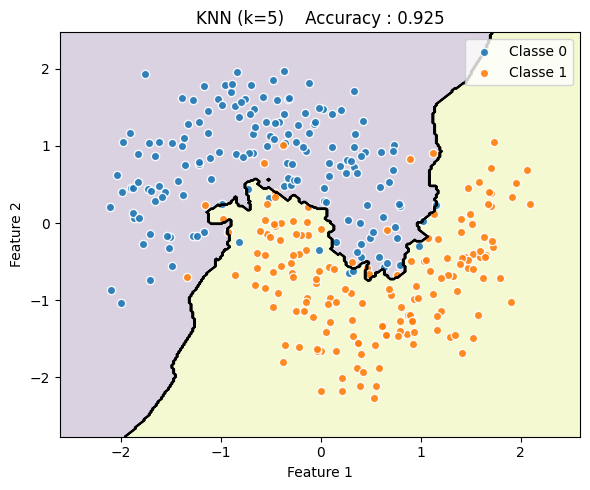

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# --- Entraîner KNN ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy KNN (k=5) : {acc_knn}")

# --- Visualiser la frontière de décision ---
x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.2)
plt.contour(xx, yy, Z, colors='black', linewidths=1.0)
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], alpha=0.9, edgecolors='white', label='Classe 0')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], alpha=0.9, edgecolors='white', label='Classe 1')
plt.title(f'KNN (k=5)    Accuracy : {acc_knn}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()

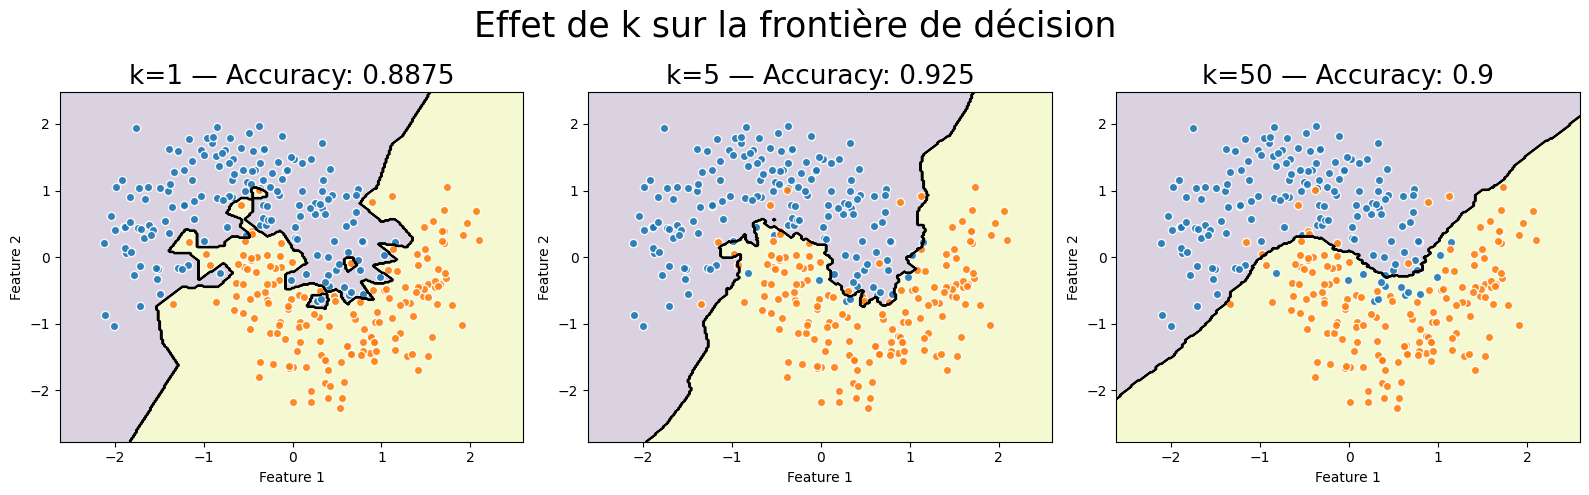

In [3]:
# --- Effet de k sur la frontière de décision ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
k_values = [1, 5, 50]

for ax, k in zip(axes, k_values):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2)
    ax.contour(xx, yy, Z, colors='black', linewidths=1.0)
    ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], alpha=0.9, edgecolors='white')
    ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], alpha=0.9, edgecolors='white')
    ax.set_title(f'k={k} — Accuracy: {acc}', fontsize=19)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle("Effet de k sur la frontière de décision", fontsize = 25)
plt.tight_layout()
plt.show()

# 4. Support Vector Machine (SVM)

## 4.1 Intuition

Imagine que vous devez séparer deux classes de dessins sur une feuille : des dessins de pommes et d'oranges. Vous voulez tracer une ligne pour les séparer.  
En théorie, il existe plusieurs façons de tracer cette ligne. Certaines passent très près des dessins, alors que d’autres laissent plus d’espace entre les deux groupes.

Le but de l'algorithme SVM est de choisir choisir la ligne qui laisse le plus grand espace possible entre les deux classes. De cette façon, il s'assure de définir la séparation qui est la plus “sécurisée” possible, en étant aussi loin que possible des dessins des deux côtés.

**Les dessins les plus proches de cette ligne sont particulièrement importants : ce sont eux qui déterminent la position de la séparation.**

- **Note importante :** Dans des dimensions plus élevées (plus de 2 features), cette ligne devient ce qu’on appelle un **hyperplan**, mais l’idée reste exactement la même.

## 4.2 Comment fonctionne-t-il?

Pour tracer sa frontière de décision (hyperplan), le SVM ne considère pas tous les points de la même manière. Les plus importants sont ceux les plus proches de la frontière.

Ces points ce nomment les **vecteurs de support** (*support vectors*). Ce sont eux qui définissent la position et l'orientation de l'hyperplan.

Mathématiquement, le SVM cherche à résoudre :

$$\max_{\mathbf{w}, b} \frac{2}{\|\mathbf{w}\|}$$

sous la contrainte que tous les points soient bien classés :

$$y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1 \quad \forall i$$

où $\mathbf{w}$ est le vecteur normal à l'hyperplan et $b$ est le biais.

(Généré avec l'IA. pour plus d'information sur le sujet, veuillez consulter: XXXX)

### 4.3 Le paramètre C (régularisation)

Dans la réalité, les données ne sont pas toujours parfaitement séparables. Le paramètre **C** contrôle le compromis entre :
- **Maximiser la marge** (C petit = marge large, plus d'erreurs tolérées)
- **Minimiser les erreurs de classification** (C grand = marge étroite, peu d'erreurs tolérées)

### 4.4 Le kernel trick

Quand les données ne sont pas linéairement séparables, lE SVM peut alors transformer les données dans un espace plus complexe où la séparation devient plus simple. On appelle cela un **kernel trick**:

- **kernel='linear' :** séparation par une droite (ou un plan)
- **kernel='rbf' :** séparation par une courbe (plus flexible)

En pratique, le Kernel permet au modèle de capturer des **relations non-linéaires**.

### 4.5 Avantages et limites

| Avantages                          | Limites                             |
|------------------------------------|-------------------------------------|
| Très performant en haute dimension | Lent sur les grands jeux de données |
| Robuste au bruit grâce à la marge  | Difficile à interpréter             |
| Efficace quand les classes sont bien séparées | Sensible au choix du kernel et de C |

Voyons voir de quoi à l'air la frontière de décision de cet algorithme et l'influence de l'hyperparamètre **C** sur la performance du modèle.

Accuracy SVM (RBF, C=1) : 0.9


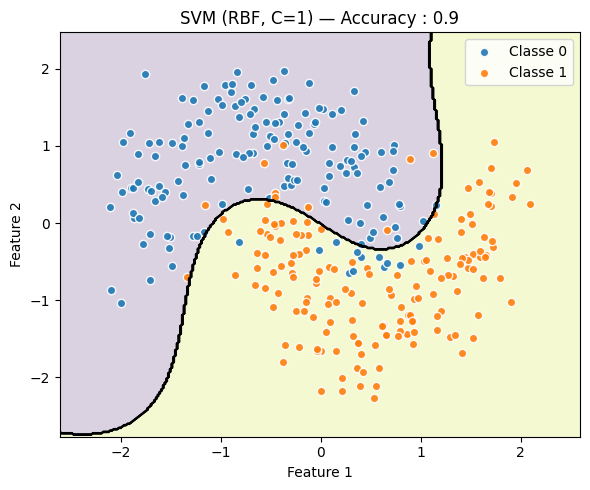

In [4]:
from sklearn.svm import SVC

# --- Entraîner SVM ---
svm = SVC(kernel='rbf', C=1.0)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy SVM (RBF, C=1) : {acc_svm}")

# --- Visualiser la frontière de décision ---
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.2)
plt.contour(xx, yy, Z, colors='black', linewidths=1.0)
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],alpha=0.9, edgecolors='white', label='Classe 0')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],alpha=0.9, edgecolors='white', label='Classe 1')

plt.title(f'SVM (RBF, C=1) — Accuracy : {acc_svm}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()

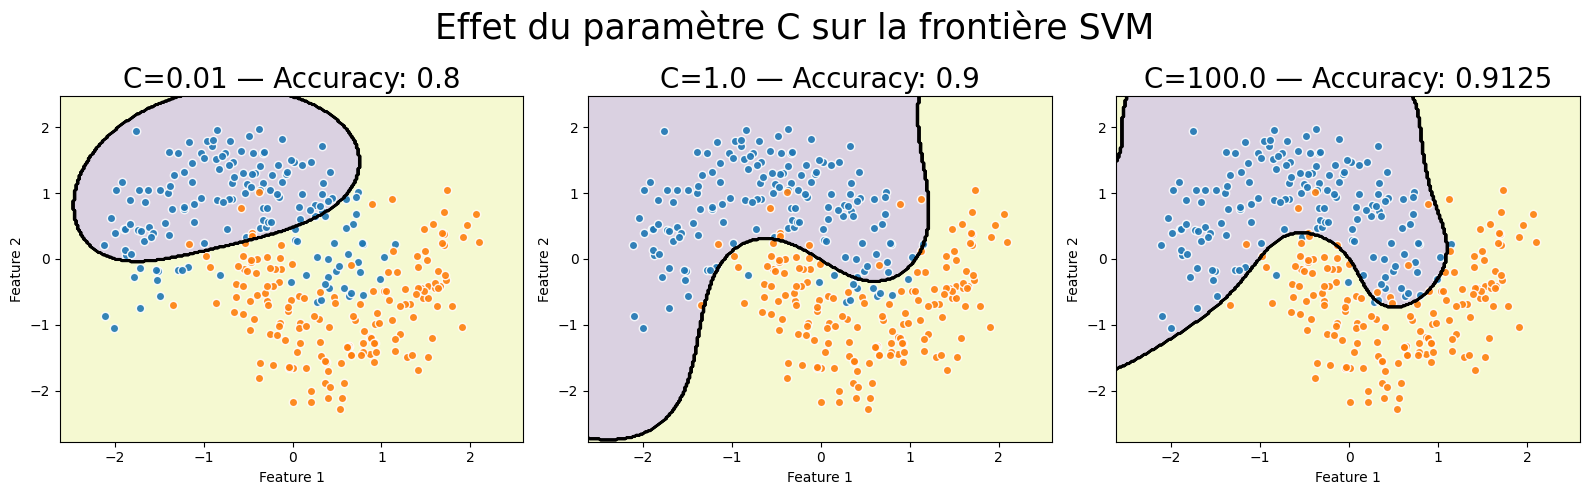

In [5]:
# --- Effet du paramètre C ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
C_values = [0.01, 1.0, 100.0]

for ax, C in zip(axes, C_values):
    clf = SVC(kernel='rbf', C=C)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2)
    ax.contour(xx, yy, Z, colors='black')
    ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], alpha=0.9, edgecolors='white')
    ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], alpha=0.9, edgecolors='white')
    ax.set_title(f'C={C} — Accuracy: {acc:}', fontsize=20)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle("Effet du paramètre C sur la frontière SVM", fontsize = 25)
plt.tight_layout()
plt.show()

# 5. Random Forest

### 5.1 Intuition

Imaginez que vous devez prendre une décision importante. Vous pourriez demander l'avis d'une seule personne, mais cette personne pourrait se tromper ou avoir des biais. Une meilleure stratégie serait donc de **consulter un grand groupe de personnes** et de prendre la décision majoritaire.

C'est exactement l'idée que le Random Forest (RF) choisi : Un seul arbre de décision peut facilement “se tromper” ou trop s’adapter aux données.  
Au lieu de lui faire confiance, on en construit plusieurs, chacun avec une vision légèrement différente du problème.

Quand vient le moment de prédire, le RF ne suit pas un seul arbre :
il regarde ce que l’ensemble des arbres pense, puis décide en prenant la réponse la plus fréquente.

### 5.2 Comment fonctionne-t-il ?

Pour être en mesure de créer les plusieurs arbres différents, deux mécanismes clés sont nécessaires:

**1. Bagging (*Bootstrap Aggregating*)**

Chaque arbre est entraîné sur une version légèrement différente des données.

En bref:
- on tire des échantillons au hasard dans les données d’entraînement
- avec remise (un même point peut apparaître plusieurs fois)

Cela fait en sorte que chaque arbre voit un jeu de donnée un peu différent.

**2. Sélection aléatoire des features**

À chaque étape de l’arbre, on ne regarde pas toutes les variables, mais seulement un sous-ensemble aléatoire.

Ainsi:
- les arbres ne prennent pas tous les mêmes décisions
- ils deviennent plus variés

La prédiction finale est obtenue par **vote majoritaire** :

$$\hat{y} = \text{mode}\left(\hat{y}_1, \hat{y}_2, \ldots, \hat{y}_T\right)$$

(Généré grâce à l'IA. Pour en savoir plus sur le sujet, veuillez consulter:
XXXX)

### 5.3 Hyperparamètres principaux:

- **`n_estimators`** : nombre d'arbres = plus il y en a, plus le modèle est stable et robuste (mais plus lent)
- **`max_depth`** : profondeur maximale de chaque arbre = contrôle l'overfitting
- **`max_features`** : nombre de features considérées à chaque nœud

### 5.4 L'importance des features

Un avantage notable des modèles RF est qu'il permet d'estimer l'importance des Features. En d'autre mot, il est possible de savoir à quel point chaque feature contribue à la prise de décision du modèle. Cela est particulièrement utile pour identifier les features les plus pertinentes.

### 5.5 Avantages et limites

| Avantages                         | Limites                              |
|-----------------------------------|--------------------------------------|
| Robuste à l'overfitting           | Moins interprétable qu'un seul arbre |
| Bon équilibre biais/variance      | Plus lent à entraîner que KNN ou SVM |
| Calcule l'importance des features | Modèle plus lourd en mémoire         |


Accuracy Random Forest (100 arbres) : 0.938


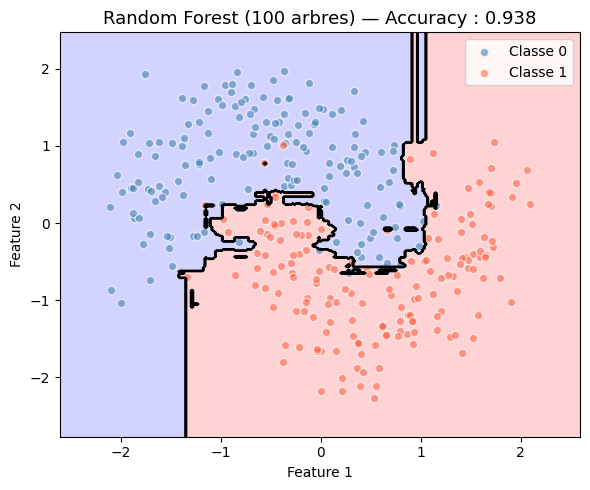

In [6]:
from sklearn.ensemble import RandomForestClassifier

# --- Entraîner Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy Random Forest (100 arbres) : {acc_rf:.3f}")

# --- Visualiser la frontière de décision ---
Z = rf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.2, cmap='bwr')
plt.contour(xx, yy, Z, colors='black', linewidths=1.0)
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
            color='steelblue', alpha=0.6, edgecolors='white', label='Classe 0')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
            color='tomato', alpha=0.6, edgecolors='white', label='Classe 1')
plt.title(f'Random Forest (100 arbres) — Accuracy : {acc_rf:.3f}', fontsize=13)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()

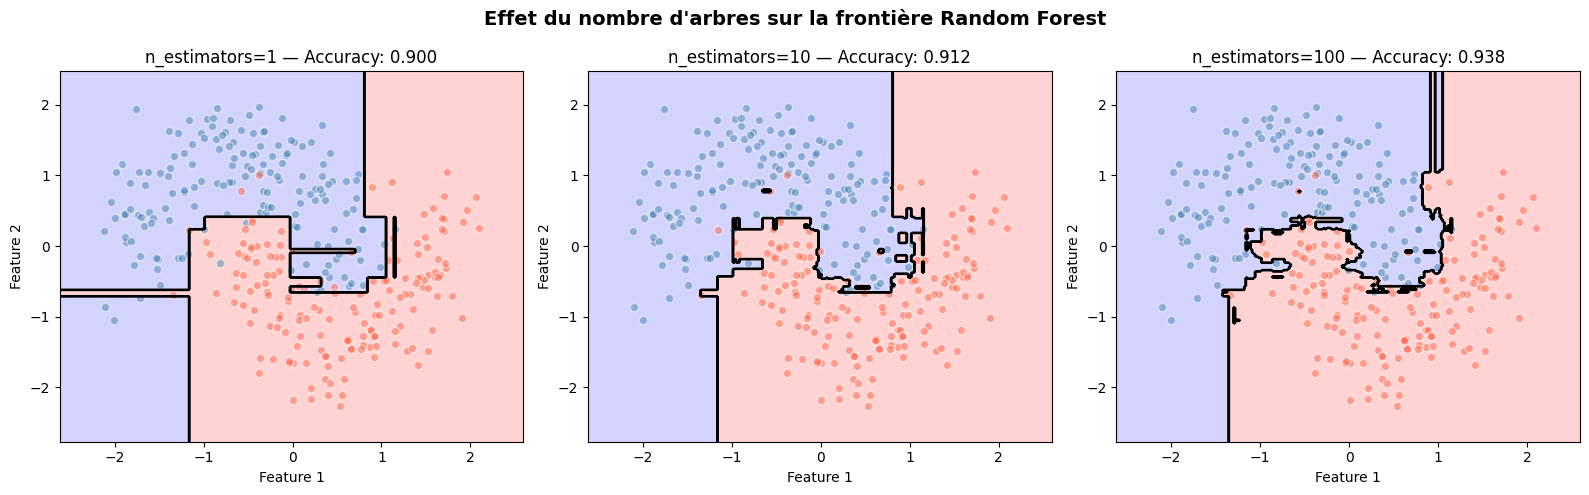

In [7]:
# --- Effet du nombre d'arbres ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
n_estimators_values = [1, 10, 100]

for ax, n in zip(axes, n_estimators_values):
    clf = RandomForestClassifier(n_estimators=n, random_state=42)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap='bwr')
    ax.contour(xx, yy, Z, colors='black', linewidths=1.0)
    ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
               color='steelblue', alpha=0.5, edgecolors='white')
    ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
               color='tomato', alpha=0.5, edgecolors='white')
    ax.set_title(f'n_estimators={n} — Accuracy: {acc:.3f}', fontsize=12)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle("Effet du nombre d'arbres sur la frontière Random Forest",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

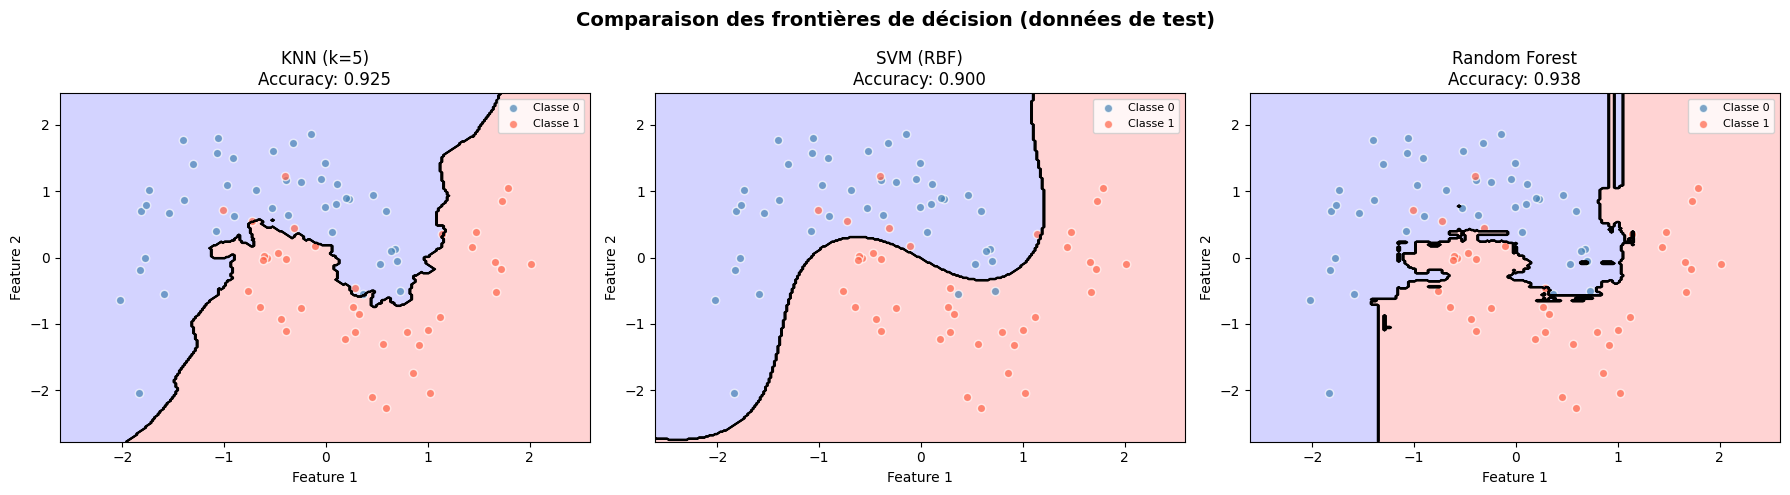

In [8]:
# --- Comparer les frontières de décision côte à côte ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    (knn, f'KNN (k=5)\nAccuracy: {acc_knn:.3f}'),
    (svm, f'SVM (RBF)\nAccuracy: {acc_svm:.3f}'),
    (rf,  f'Random Forest\nAccuracy: {acc_rf:.3f}'),
]

for ax, (model, title) in zip(axes, models):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap='bwr')
    ax.contour(xx, yy, Z, colors='black', linewidths=1.0)
    ax.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1],
               color='steelblue', alpha=0.7, edgecolors='white', label='Classe 0')
    ax.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1],
               color='tomato', alpha=0.7, edgecolors='white', label='Classe 1')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(fontsize=8)

plt.suptitle('Comparaison des frontières de décision (données de test)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

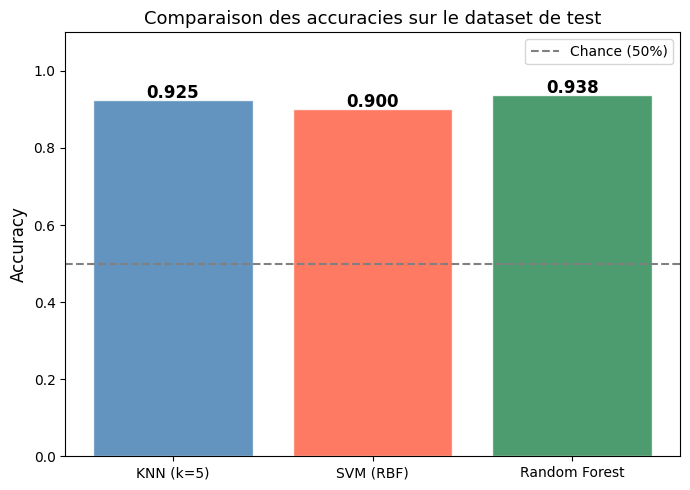

In [9]:
# --- Graphique comparatif des accuracies ---
models_names = ['KNN (k=5)', 'SVM (RBF)', 'Random Forest']
accuracies = [acc_knn, acc_svm, acc_rf]
colors_bar = ['steelblue', 'tomato', 'seagreen']

plt.figure(figsize=(7, 5))
bars = plt.bar(models_names, accuracies, color=colors_bar, alpha=0.85, edgecolor='white')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             acc + 0.005,
             f'{acc:.3f}',
             ha='center', fontsize=12, fontweight='bold')

plt.axhline(0.5, color='grey', linestyle='--', linewidth=1.5, label='Chance (50%)')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Comparaison des accuracies sur le dataset de test', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

Dans ce notebook, nous avons exploré trois algorithmes de classification classiques — **KNN**, **SVM** et **Random Forest** — en les entraînant et en les comparant sur le même jeu de données.

Comme le prédit le **No Free Lunch Theorem**, aucun des trois modèles n'est universellement meilleur. Chacun a ses forces et ses limites selon le contexte :

- **KNN** : simple et intuitif, mais lent sur les grands datasets et sensible à l'échelle des features
- **SVM** : excellent pour les données de haute dimension et les frontières complexes grâce au kernel trick, mais difficile à interpréter
- **Random Forest** : souvent le meilleur compromis — robuste, performant, et capable de mesurer l'importance des features

En pratique, le choix d'un algorithme dépend toujours du problème : la taille des données, le nombre de features, le besoin d'interprétabilité et le temps disponible pour l'entraînement.

BIBLIOGRAPHIE
https://www.markdownguide.org/basic-syntax/
https://www.markdownguide.org/extended-syntax/
https://mystmd.org/guide/typography
https://emojipedia.org

https://machinelearningmastery.com/no-free-lunch-theorem-for-machine-learning/

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbours/
https://en.wikipedia.org/wiki/Euclidean_distance

https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
https://www.geeksforgeeks.org/machine-learning/support-vector-machine-algorithm/
https://scikit-learn.org/stable/modules/svm.html

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html
https://distill.pub/2016/misread-tsne/

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contourf.html
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html